# Bond Pricing — A Beginner's Guide with Graphs

This notebook explains how bonds work and how they are priced, from the very basics up through professional risk metrics. No prior finance knowledge is required.

## What is a bond?

A **bond** is a loan. When you buy a bond, you are lending money to the issuer (a government or company). In return, they promise to:
1. Pay you a regular **interest payment** (called a **coupon**) every year
2. Return your original **principal** (the **face value**) at the end of the loan period (the **maturity date**)

**Real-world examples:**
- A government issues a 10-year bond to fund infrastructure spending. Investors lend money now and receive interest annually plus principal back in 10 years.
- A company issues a 5-year bond to finance expansion. The coupon is the price the company pays to borrow.

## Why do investors buy bonds?
- **Predictable income**: coupons arrive on a fixed schedule — useful for pension funds, retirees, and insurance companies
- **Capital preservation**: at maturity, the full face value is returned (assuming no default)
- **Portfolio diversification**: bonds often move differently from equities

## Key terms explained

| Term | Plain-language meaning | Example |
|---|---|---|
| **Face value (par value)** | The amount the bond repays at maturity | $100,000 |
| **Coupon rate** | Annual interest rate stated in the contract | 5% per year |
| **Coupon payment** | The actual cash paid each year | 5% × $100,000 = $5,000 |
| **Maturity** | How many years until the principal is returned | 10 years |
| **Market price** | What you can buy/sell the bond for today | $98,500 (could be above or below par) |
| **Yield to maturity (YTM)** | The return you earn if you buy now and hold to maturity | 5.2% |
| **Basis point (bp)** | One-hundredth of one percent: 1 bp = 0.01% | Rate moves from 5.00% to 5.01% = 1 bp |

## What this notebook covers

| Section | Topic |
|---|---|
| 1 | Core pricing — how to calculate a bond's fair price |
| 2 | Cash flow timeline — visualising what you receive and when |
| 3 | What yield to maturity is and how it is calculated |
| 4 | Portfolio of bonds — metrics like duration, DV01, convexity |
| 5 | Interest rates and bond prices — the inverse relationship |
| 6 | OTR vs XTR bonds — liquidity, relative value, hedging |

## Suggested reading path
**New to bonds?** Read every section. The first two are the most important conceptually.
**Know basic pricing?** Jump to Section 4 for risk metrics.

## Modeling assumptions in this notebook
- Annual coupon payments (real bonds may pay semi-annually)
- Fixed face value per bond (stated explicitly)
- No credit risk or default probability
- No accrued interest calculations
- Flat yield discounting (one yield for all cash flows of a bond)

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RNG = np.random.default_rng(42)

## 1. Core Bond Pricing Concepts

### 1.1 The fundamental question: what is a bond worth today?

A bond promises to pay you money in the future. But money received in the future is worth less than money in your hand today — because money you have today can be invested to earn a return.

**Bond pricing** answers the question: *"What is the fair price today for a stream of future cash payments?"*

The answer is to **discount** each future payment back to today using the market interest rate (the yield).

---

### 1.2 Step-by-step: pricing a 3-year, 5% coupon bond

Suppose the bond has:
- Face value: $100,000
- Coupon rate: 5% per year → pays $5,000/year
- Maturity: 3 years
- Market yield (YTM): 4%

The cash flows are:
| Year | Payment | Type |
|------|---------|------|
| 1 | $5,000 | Coupon |
| 2 | $5,000 | Coupon |
| 3 | $105,000 | Final coupon + principal |

To get today's value, we discount each cash flow:

$$PV_1 = \frac{5{,}000}{(1.04)^1} = 4{,}808$$

$$PV_2 = \frac{5{,}000}{(1.04)^2} = 4{,}623$$

$$PV_3 = \frac{105{,}000}{(1.04)^3} = 93{,}348$$

$$\text{Bond price} = 4{,}808 + 4{,}623 + 93{,}348 = \mathbf{102{,}779}$$

The bond trades **above par** ($100,000) because its coupon (5%) is higher than the market yield (4%). Investors pay a premium for the above-market coupon.

---

### 1.3 The general pricing formula

For a bond with annual coupons:

$$P(y) = \sum_{t=1}^{n} \frac{C}{(1+y)^t} + \frac{F}{(1+y)^n}$$

where:
- $P(y)$ = bond price at yield $y$
- $C = F \times \text{coupon rate}$ = annual coupon payment
- $F$ = face value (principal)
- $n$ = maturity in years
- $y$ = yield to maturity

Each term $\frac{C}{(1+y)^t}$ is the present value of one coupon payment. The last term is the discounted return of principal.

---

### 1.4 Yield to Maturity (YTM) — the most important number

**YTM** is the single discount rate that makes the present value of all future cash flows exactly equal to the current market price.

In other words: **YTM is the return you earn if you buy the bond today at its market price and hold it to maturity**, assuming you reinvest coupons at the same rate.

There is no formula to solve for YTM directly — it requires an iterative numerical solution (we use bisection search). The chart below shows this visually: we find the yield where `PV(cash flows) − market price = 0`.

**Three key cases:**

| Situation | Price vs Par | Why |
|---|---|---|
| Coupon rate > YTM | **Above par (premium)** | Bond pays more than market rate → investors pay extra |
| Coupon rate = YTM | **At par** | Bond pays exactly market rate |
| Coupon rate < YTM | **Below par (discount)** | Bond pays less than market rate → price falls to compensate |

---

### 1.5 The inverse price-yield relationship

**The most important rule in bond markets:**

> When yields rise, bond prices fall. When yields fall, bond prices rise.

**Why?** The coupon is fixed. If market rates rise, new bonds offer higher coupons. Your old bond with a lower coupon is less attractive — so its price must fall until its return matches the new market rate.

**Analogy:** Imagine you own a bond paying $50/year. Suddenly new bonds are paying $70/year. Nobody will pay $1,000 for your bond anymore — they can get more elsewhere. Your bond's price drops until it offers a competitive return.

---

### 1.6 Risk metrics: how much does the price move?

| Metric | What it measures | Formula concept |
|---|---|---|
| **Macaulay duration** | Weighted average time to receive cash flows (in years) | Higher = cash flows arrive later |
| **Modified duration** | % price change per 1% yield change | $D_{mac} / (1+y)$ |
| **DV01** | $ price change per 1 bp yield change | Numerical: price up − price down for 1 bp bump |
| **Convexity** | Curvature of price-yield relationship | Improves duration estimate for large moves |

**Duration approximation** — for a small yield change $\Delta y$:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y$$

A bond with modified duration of 7 years loses approximately 7% of its value if yields rise by 1% (100 bp).

**Adding convexity** improves accuracy for larger moves:

$$\frac{\Delta P}{P} \approx -D_{mod} \cdot \Delta y + \frac{1}{2} \cdot C \cdot (\Delta y)^2$$

The convexity term is always positive, meaning the actual price loss is slightly less than duration alone predicts (bonds benefit from convexity).

In [2]:
@dataclass
class Bond:
    name: str
    face_value: float
    coupon_rate: float
    maturity_years: int
    market_yield: float

    @property
    def coupon_payment(self) -> float:
        return self.face_value * self.coupon_rate


def cash_flows(face_value: float, coupon_rate: float, maturity_years: int) -> tuple[np.ndarray, np.ndarray]:
    periods = np.arange(1, maturity_years + 1)
    flows = np.full(maturity_years, face_value * coupon_rate, dtype=float)
    flows[-1] += face_value
    return periods, flows


def price_from_ytm(face_value: float, coupon_rate: float, maturity_years: int, ytm: float) -> float:
    periods, flows = cash_flows(face_value, coupon_rate, maturity_years)
    discount_factors = (1 + ytm) ** periods
    return float(np.sum(flows / discount_factors))


def ytm_from_price(face_value: float, coupon_rate: float, maturity_years: int, price: float, lower: float = 1e-6, upper: float = 0.30, tol: float = 1e-10) -> float:
    def objective(rate: float) -> float:
        return price_from_ytm(face_value, coupon_rate, maturity_years, rate) - price

    lower_value = objective(lower)
    upper_value = objective(upper)
    if lower_value * upper_value > 0:
        raise ValueError("Bisection bounds do not bracket the bond yield.")

    for _ in range(200):
        midpoint = (lower + upper) / 2
        midpoint_value = objective(midpoint)
        if abs(midpoint_value) < tol:
            return midpoint
        if lower_value * midpoint_value <= 0:
            upper = midpoint
            upper_value = midpoint_value
        else:
            lower = midpoint
            lower_value = midpoint_value
    return midpoint


def macaulay_duration(face_value: float, coupon_rate: float, maturity_years: int, ytm: float) -> float:
    periods, flows = cash_flows(face_value, coupon_rate, maturity_years)
    present_values = flows / ((1 + ytm) ** periods)
    price = np.sum(present_values)
    return float(np.sum(periods * present_values) / price)


def modified_duration(face_value: float, coupon_rate: float, maturity_years: int, ytm: float) -> float:
    return macaulay_duration(face_value, coupon_rate, maturity_years, ytm) / (1 + ytm)


def convexity(face_value: float, coupon_rate: float, maturity_years: int, ytm: float) -> float:
    periods, flows = cash_flows(face_value, coupon_rate, maturity_years)
    present_values = flows / ((1 + ytm) ** periods)
    price = np.sum(present_values)
    convexity_value = np.sum(present_values * periods * (periods + 1)) / (price * (1 + ytm) ** 2)
    return float(convexity_value)


def dv01(face_value: float, coupon_rate: float, maturity_years: int, ytm: float) -> float:
    price_up = price_from_ytm(face_value, coupon_rate, maturity_years, ytm + 0.0001)
    price_down = price_from_ytm(face_value, coupon_rate, maturity_years, ytm - 0.0001)
    return float((price_down - price_up) / 2)


def approximate_price_change(price: float, mod_duration: float, convexity_value: float, delta_yield: float) -> float:
    return price * (-mod_duration * delta_yield + 0.5 * convexity_value * delta_yield ** 2)

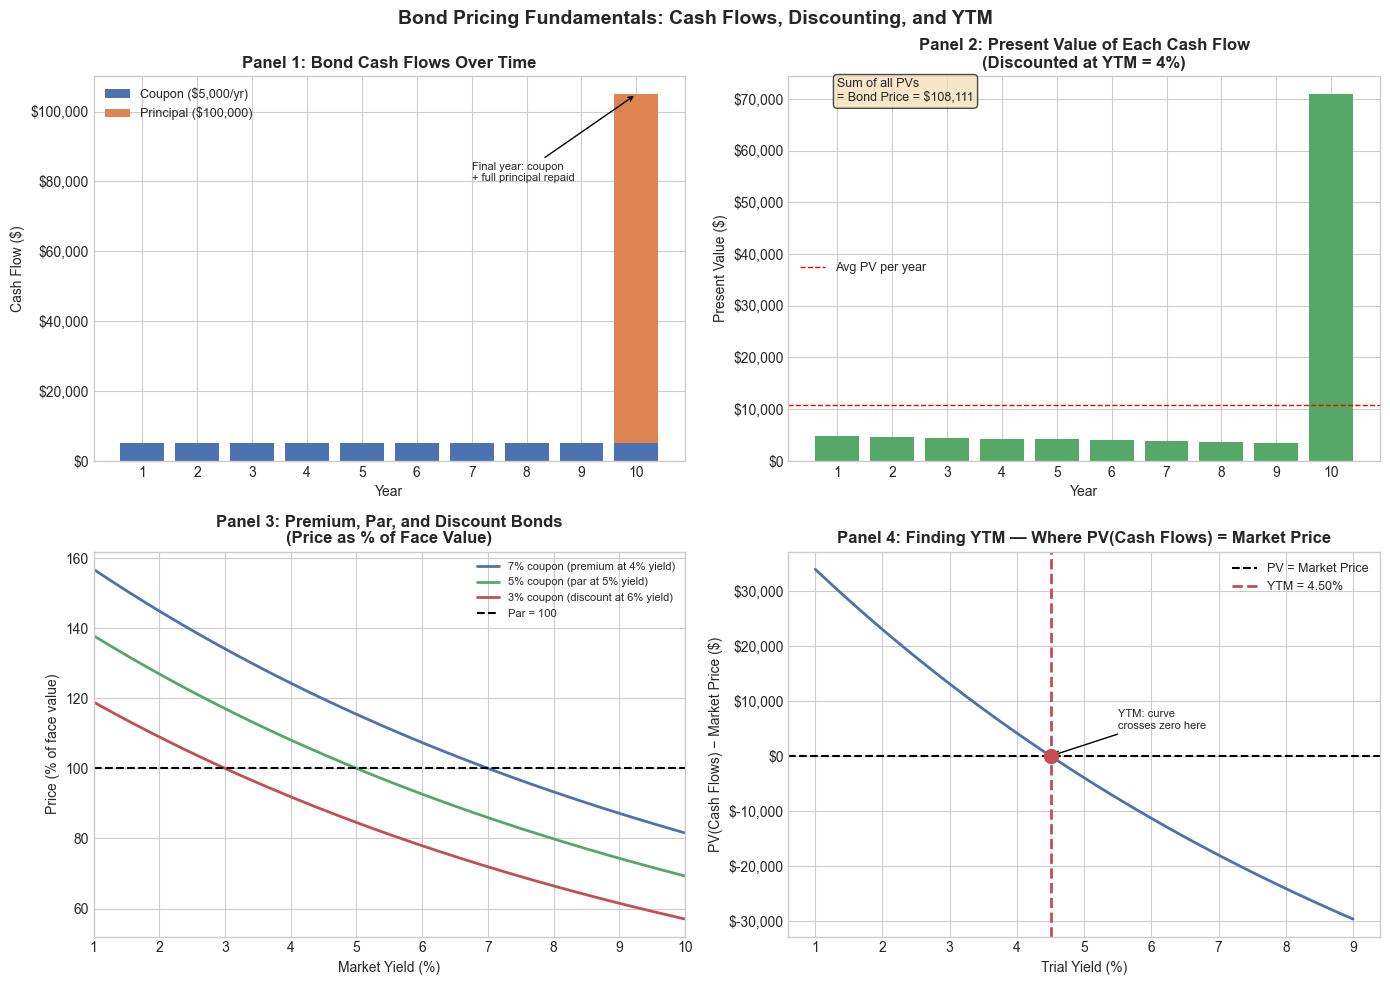

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bond Pricing Fundamentals: Cash Flows, Discounting, and YTM", fontsize=14, fontweight="bold")

face = 100_000
coupon_r = 0.05
mat = 10
ytm_ex = 0.04
periods = np.arange(1, mat + 1)
coupons = np.full(mat, face * coupon_r)
principals = np.zeros(mat)
principals[-1] = face

# --- Panel 1: Cash flow timeline ---
ax = axes[0, 0]
ax.bar(periods, coupons, color="#4C72B0", label=f"Coupon (${face * coupon_r:,.0f}/yr)")
ax.bar(periods, principals, bottom=coupons, color="#DD8452", label=f"Principal (${face:,.0f})")
ax.set_title("Panel 1: Bond Cash Flows Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cash Flow ($)")
ax.set_xticks(periods)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9)
ax.annotate("Final year: coupon\n+ full principal repaid", xy=(mat, face + face * coupon_r),
            xytext=(mat - 3, face * 0.8), arrowprops=dict(arrowstyle="->", color="black"), fontsize=8)

# --- Panel 2: Present value of each cash flow ---
ax = axes[0, 1]
all_cfs = coupons.copy()
all_cfs[-1] += face
pv_cfs = all_cfs / (1 + ytm_ex) ** periods
ax.bar(periods, pv_cfs, color="#55A868")
ax.set_title(f"Panel 2: Present Value of Each Cash Flow\n(Discounted at YTM = {ytm_ex*100:.0f}%)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Present Value ($)")
ax.set_xticks(periods)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
total_pv = pv_cfs.sum()
ax.axhline(total_pv / mat, color="red", linestyle="--", linewidth=1, label=f"Avg PV per year")
ax.text(1, pv_cfs.max() * 0.98, f"Sum of all PVs\n= Bond Price = ${total_pv:,.0f}", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
ax.legend(fontsize=9)

# --- Panel 3: Premium, par, discount bonds ---
ax = axes[1, 0]
yield_range = np.linspace(0.01, 0.10, 200)
mat3 = 10
for cr, lbl, clr in [(0.07, "7% coupon (premium at 4% yield)", "#4C72B0"),
                      (0.05, "5% coupon (par at 5% yield)", "#55A868"),
                      (0.03, "3% coupon (discount at 6% yield)", "#C44E52")]:
    prices = [price_from_ytm(face, cr, mat3, y) / face * 100 for y in yield_range]
    ax.plot(yield_range * 100, prices, color=clr, linewidth=2, label=lbl)
ax.axhline(100, color="black", linestyle="--", linewidth=1.5, label="Par = 100")
ax.set_title("Panel 3: Premium, Par, and Discount Bonds\n(Price as % of Face Value)", fontweight="bold")
ax.set_xlabel("Market Yield (%)")
ax.set_ylabel("Price (% of face value)")
ax.legend(fontsize=8)
ax.set_xlim(1, 10)

# --- Panel 4: YTM root-finding visual ---
ax = axes[1, 1]
market_price = price_from_ytm(face, coupon_r, mat, 0.0450)
trial_yields = np.linspace(0.01, 0.09, 300)
pv_minus_price = [
    sum((face * coupon_r) / (1 + y) ** t + (face if t == mat else 0) / (1 + y) ** t
        for t in range(1, mat + 1)) - market_price
    for y in trial_yields
]
ax.plot(trial_yields * 100, pv_minus_price, color="#4C72B0", linewidth=2)
ax.axhline(0, color="black", linewidth=1.5, linestyle="--", label="PV = Market Price")
ytm_sol = ytm_from_price(face, coupon_r, mat, market_price)
ax.axvline(ytm_sol * 100, color="#C44E52", linewidth=2, linestyle="--", label=f"YTM = {ytm_sol*100:.2f}%")
ax.scatter([ytm_sol * 100], [0], color="#C44E52", s=100, zorder=5)
ax.set_title("Panel 4: Finding YTM — Where PV(Cash Flows) = Market Price", fontweight="bold")
ax.set_xlabel("Trial Yield (%)")
ax.set_ylabel("PV(Cash Flows) − Market Price ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9)
ax.annotate("YTM: curve\ncrosses zero here", xy=(ytm_sol * 100, 0),
            xytext=(ytm_sol * 100 + 1, 5000), arrowprops=dict(arrowstyle="->", color="black"), fontsize=8)

plt.tight_layout()
plt.show()

### How to read this chart

**Panel 1 — Cash flow timeline:**
Blue bars are the annual coupon payments (same height every year — fixed cash flows). The tall orange+blue bar at year 10 is the coupon *plus* the full $100,000 principal repayment. Most of a bond's cash value is concentrated in that final bar.

**Panel 2 — Present value of each cash flow:**
Each bar shows what the corresponding cash flow is worth *today* after discounting. Notice the bars shrink slightly from year 1 to year 9 (earlier coupons are worth slightly more because they arrive sooner), then spike at year 10 (large final payment). The annotation shows that all bars added together equal the bond price.

**Panel 3 — Premium, par, and discount bonds:**
All three lines show the same thing: price falls as yield rises. The 7% coupon bond (blue) sits above the 5% (green) and 3% (red) across all yields — it always has more income to offer. Each line crosses the par (100%) line exactly at the yield equal to its coupon rate. 

**Panel 4 — Finding YTM:**
This shows why YTM requires iteration. The blue curve shows the difference between the present value of cash flows and the market price, for each trial yield. At low yields, PV > market price (positive difference). At high yields, PV < market price (negative difference). The YTM is the exact yield where the curve crosses zero — marked by the red dot.

In [3]:
maturities = np.array([2, 3, 5, 7, 10, 15, 20, 30])
base_curve = 0.022 + 0.0013 * np.sqrt(maturities) + 0.00035 * maturities
coupon_rates = np.clip(base_curve + RNG.normal(0, 0.006, size=len(maturities)), 0.015, 0.075)
market_yields = np.clip(base_curve + RNG.normal(0, 0.004, size=len(maturities)), 0.015, 0.09)
face_values = RNG.integers(500_000, 2_000_000, size=len(maturities))

portfolio = [
    Bond(
        name=f"Bond {maturity}Y",
        face_value=float(face_value),
        coupon_rate=float(coupon_rate),
        maturity_years=int(maturity),
        market_yield=float(market_yield),
    )
    for maturity, face_value, coupon_rate, market_yield in zip(maturities, face_values, coupon_rates, market_yields)
]

records = []
for bond in portfolio:
    price = price_from_ytm(bond.face_value, bond.coupon_rate, bond.maturity_years, bond.market_yield)
    inferred_ytm = ytm_from_price(bond.face_value, bond.coupon_rate, bond.maturity_years, price)
    macaulay = macaulay_duration(bond.face_value, bond.coupon_rate, bond.maturity_years, inferred_ytm)
    modified = modified_duration(bond.face_value, bond.coupon_rate, bond.maturity_years, inferred_ytm)
    convexity_value = convexity(bond.face_value, bond.coupon_rate, bond.maturity_years, inferred_ytm)
    dv01_value = dv01(bond.face_value, bond.coupon_rate, bond.maturity_years, inferred_ytm)

    records.append(
        {
            "bond": bond.name,
            "face_value": bond.face_value,
            "coupon_rate": bond.coupon_rate,
            "coupon_payment": bond.coupon_payment,
            "maturity_years": bond.maturity_years,
            "market_yield": bond.market_yield,
            "price": price,
            "price_pct_of_par": price / bond.face_value,
            "current_yield": bond.coupon_payment / price,
            "ytm_recovered": inferred_ytm,
            "macaulay_duration": macaulay,
            "modified_duration": modified,
            "dv01": dv01_value,
            "convexity": convexity_value,
        }
    )

portfolio_df = pd.DataFrame(records).sort_values("maturity_years").reset_index(drop=True)
portfolio_df

,bond,face_value,coupon_rate,coupon_payment,maturity_years,market_yield,price,price_pct_of_par,current_yield,ytm_recovered,macaulay_duration,modified_duration,dv01,convexity
0,Bond 2Y,"638,203.0000",0.0264,"16,827.3582",2,0.0245,"640,536.4382",1.0037,0.0263,0.0245,1.9744,1.9272,123.4439,5.6191
1,Bond 3Y,"1,331,877.0000",0.0191,"25,387.9216",3,0.0219,"1,321,055.6073",0.9919,0.0192,0.0219,2.9440,2.8809,380.5859,11.2056
2,Bond 5Y,"1,831,834.0000",0.0312,"57,079.2065",5,0.0302,"1,840,094.2759",1.0045,0.0310,0.0302,4.7076,4.5697,840.8665,26.0721
3,Bond 7Y,"595,725.0000",0.0335,"19,976.3660",7,0.0310,"605,088.0840",1.0157,0.0330,0.0310,6.3603,6.1690,373.2797,46.3035
4,Bond 10Y,"1,787,436.0000",0.0179,"32,003.5944",10,0.0299,"1,604,805.6174",0.8978,0.0199,0.0299,9.1927,8.9261,"1,432.4594",92.6551
5,Bond 15Y,"1,741,446.0000",0.0245,"42,616.3205",15,0.0368,"1,497,426.8739",0.8599,0.0285,0.0368,12.5173,12.0731,"1,807.8568",174.9256
6,Bond 20Y,"915,139.0000",0.0356,"32,561.3953",20,0.0367,"901,009.2242",0.9846,0.0361,0.0367,14.5933,14.0769,"1,268.3454",253.5585
7,Bond 30Y,"1,447,496.0000",0.0377,"54,603.8014",30,0.0362,"1,487,885.9344",1.0279,0.0367,0.0362,18.6182,17.9680,"2,673.4432",444.8326


### How to read the portfolio table

Each row is one bond in the portfolio. Scan across columns left to right:

1. **`face_value` + `coupon_rate`** → `coupon_payment` (simply: face × rate). This is the fixed annual income.
2. **`market_yield` vs `coupon_rate`** → if market yield < coupon, the bond is a premium (`price_pct_of_par > 1.0`). If market yield > coupon, the bond is a discount (`price_pct_of_par < 1.0`).
3. **`modified_duration`** → multiply by any yield change (as a decimal) to estimate the % price impact. For example: modified duration of 8 × 0.01 yield rise = approximately −8% price change.
4. **`dv01`** → tells you how many dollars this bond loses for every 1 basis point (0.01%) yield rise. Sum DV01 across all bonds to see the total portfolio sensitivity.
5. **`ytm_recovered` ≈ `market_yield`** → this should match almost exactly (round-trip check: price the bond from yield, then recover the yield from the price).

## 2. Interest Rates, Bond Yields, and Prices

### 2.1 Interest rates vs bond yields — what is the difference?

**Interest rates** are set by central banks and money markets. They represent the general cost of borrowing across the economy.

**Bond yields** are the return required by investors to hold a specific bond at its current market price. They move in response to:
- Central bank rate decisions
- Inflation expectations
- Credit risk of the issuer
- Supply/demand for that specific bond

Yield is how the bond market "transmits" changes in interest rates into prices. When central banks raise rates, newly issued bonds pay higher coupons — so existing bonds (with fixed lower coupons) must fall in price to offer competitive yields.

### 2.2 The price-yield mechanism

Think of a bond like a rental apartment:
- The **rent (coupon)** is fixed in the contract
- If the **market rental rate** (yield) rises, your fixed-rent apartment is less attractive
- To sell it, you must lower the **price**
- A lower price means the buyer gets a better total return (yield) from the same fixed rent

The market adjusts the **price** of existing bonds until their yield matches what investors can get elsewhere.

### 2.3 Why longer bonds are more sensitive

A 2-year bond gets its principal back in 2 years. Most of its value sits in that near-term repayment, which is not heavily discounted.

A 30-year bond gets its principal back 30 years from now. By then, discounting has shrunk that payment enormously. Small changes in the yield dramatically affect the present value of distant cash flows.

**Rule of thumb:** doubling the maturity roughly doubles the duration and doubles the price sensitivity.

### 2.4 The yield curve

The **yield curve** plots the yield at each maturity — 1Y, 2Y, 5Y, 10Y, 30Y. Its shape tells you a lot:

| Curve shape | What it usually means |
|---|---|
| **Normal (upward slope)** | Longer bonds pay more — investors need compensation for locking up money longer |
| **Inverted** | Short-term rates are higher than long-term — often signals recession fears or expected future rate cuts |
| **Flat** | All maturities yield roughly the same — uncertain outlook |

### 2.5 What the charts below show

The two charts compare:
1. **Price vs yield** across the full yield range for three bonds (short, medium, long-dated) — showing the curved (convex) price-yield relationship
2. **Price sensitivity to a rate shock** — showing how the same 50 bp move has very different impacts depending on maturity

Look for:
- The inverse slope (prices falling as yields rise)
- The curvature (convexity) — prices fall less for a 100 bp rise than they gain for a 100 bp fall
- Long-dated bonds having steeper slopes (larger sensitivity)

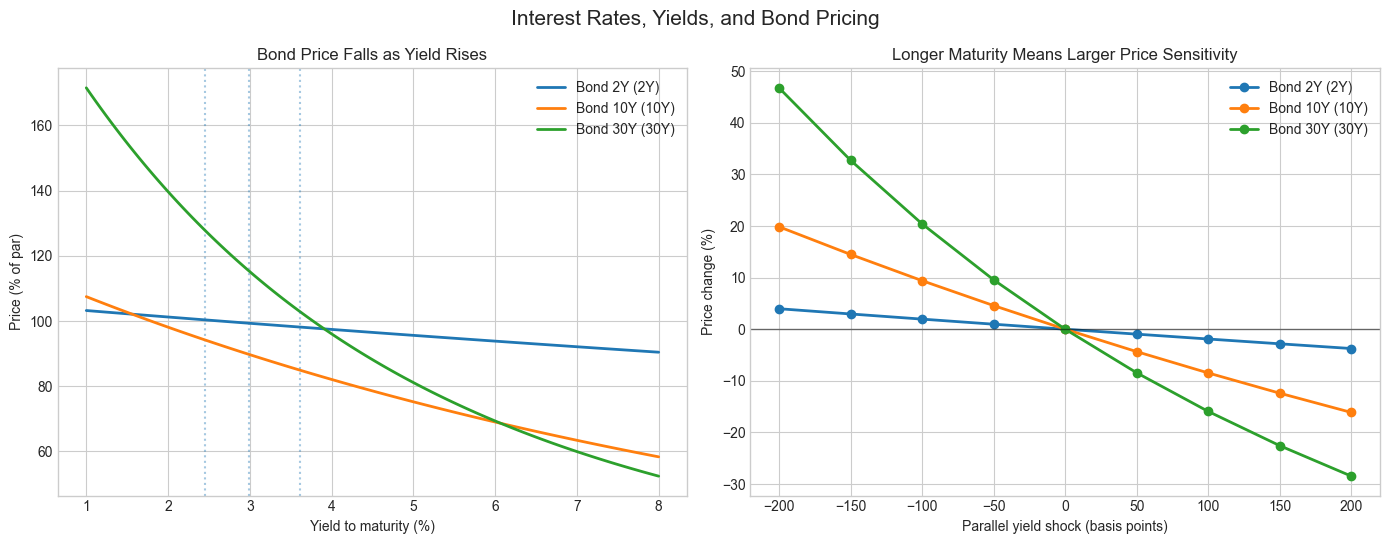

In [8]:
selected_bonds = [portfolio[0], portfolio[4], portfolio[-1]]
yield_grid = np.linspace(0.01, 0.08, 120)
curve_rows = []
shock_bp = np.arange(-200, 225, 50)
shock_rows = []

for bond in selected_bonds:
    base_price = price_from_ytm(bond.face_value, bond.coupon_rate, bond.maturity_years, bond.market_yield)
    for ytm in yield_grid:
        curve_rows.append(
            {
                "bond": bond.name,
                "maturity_years": bond.maturity_years,
                "yield_pct": 100 * ytm,
                "price_pct_of_par": 100 * price_from_ytm(bond.face_value, bond.coupon_rate, bond.maturity_years, ytm) / bond.face_value,
            }
        )
    for shock in shock_bp:
        shocked_yield = bond.market_yield + shock / 10_000
        shocked_price = price_from_ytm(bond.face_value, bond.coupon_rate, bond.maturity_years, shocked_yield)
        shock_rows.append(
            {
                "bond": bond.name,
                "maturity_years": bond.maturity_years,
                "shock_bp": shock,
                "pct_price_change": 100 * (shocked_price - base_price) / base_price,
            }
        )

curve_df = pd.DataFrame(curve_rows)
shock_sensitivity_df = pd.DataFrame(shock_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for bond in selected_bonds:
    bond_curve = curve_df[curve_df["bond"] == bond.name]
    axes[0].plot(bond_curve["yield_pct"], bond_curve["price_pct_of_par"], linewidth=2, label=f"{bond.name} ({bond.maturity_years}Y)")
    axes[0].axvline(100 * bond.market_yield, linestyle=":", alpha=0.4)
axes[0].set_title("Bond Price Falls as Yield Rises")
axes[0].set_xlabel("Yield to maturity (%)")
axes[0].set_ylabel("Price (% of par)")
axes[0].legend()

for bond in selected_bonds:
    bond_shock = shock_sensitivity_df[shock_sensitivity_df["bond"] == bond.name]
    axes[1].plot(bond_shock["shock_bp"], bond_shock["pct_price_change"], marker="o", linewidth=2, label=f"{bond.name} ({bond.maturity_years}Y)")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Longer Maturity Means Larger Price Sensitivity")
axes[1].set_xlabel("Parallel yield shock (basis points)")
axes[1].set_ylabel("Price change (%)")
axes[1].legend()

fig.suptitle("Interest Rates, Yields, and Bond Pricing", fontsize=15)
fig.tight_layout()
plt.show()

### How to read the price sensitivity charts

**Left chart — Price vs Yield for three bonds:**
Three curves, each for a bond at a different maturity (short ~2Y, medium ~5Y, long ~10Y+). All curves slope downward (price falls as yield rises — the fundamental inverse relationship). Notice:
- The curves are not straight lines — they bow *outward* (convex). That bowing is convexity.
- Longer-maturity bonds have steeper curves — they lose more value per % yield rise.
- All three bonds converge toward their face value at very high yields (since the principal still gets repaid at maturity).

**Right chart — Price reaction to a ±50 bp rate shock:**
Each bar shows how much the price changes if yields move +50 bp (rise) or −50 bp (fall) from today. Notice:
- Longer bonds have taller bars — more sensitivity.
- The absolute fall (from a +50 bp shock) is slightly smaller than the absolute rise (from a −50 bp shock) — this is convexity working in the investor's favour.

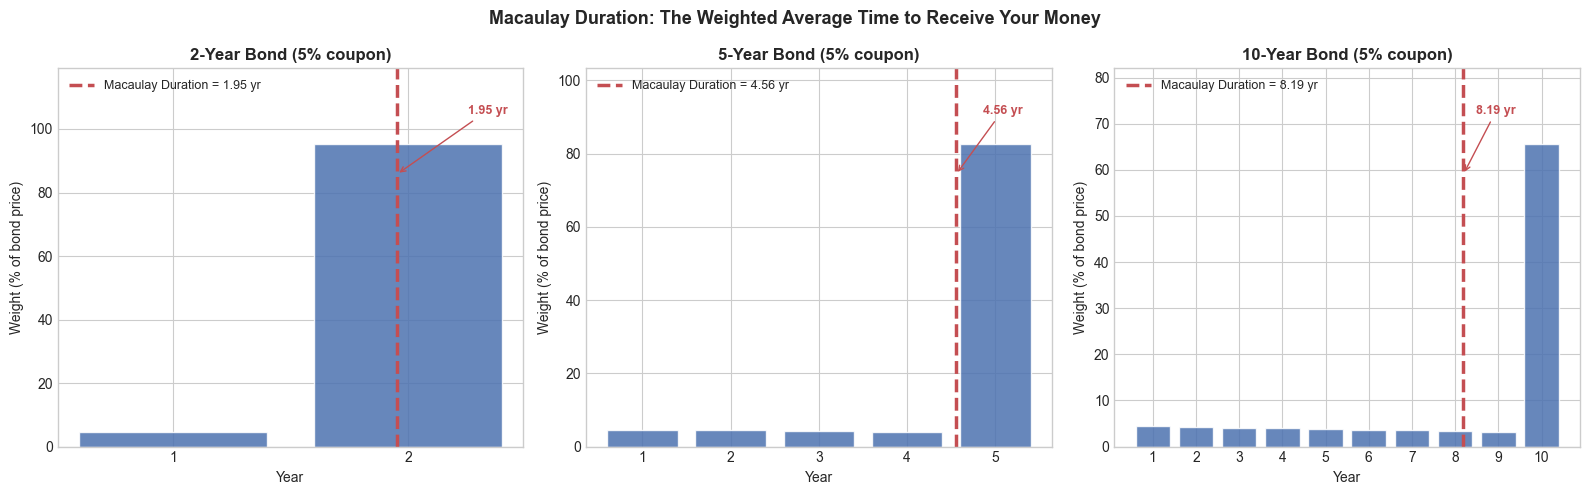

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Macaulay Duration: The Weighted Average Time to Receive Your Money", fontsize=13, fontweight="bold")

ytm_dur = 0.04
configs = [
    (100_000, 0.05, 2, "2-Year Bond (5% coupon)"),
    (100_000, 0.05, 5, "5-Year Bond (5% coupon)"),
    (100_000, 0.05, 10, "10-Year Bond (5% coupon)"),
]

for ax, (fv, cr, mat_d, title) in zip(axes, configs):
    periods_d = np.arange(1, mat_d + 1)
    cfs_d = np.full(mat_d, fv * cr, dtype=float)
    cfs_d[-1] += fv
    pv_d = cfs_d / (1 + ytm_dur) ** periods_d
    weights = pv_d / pv_d.sum()
    mac_dur = float((weights * periods_d).sum())

    ax.bar(periods_d, weights * 100, color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.axvline(mac_dur, color="#C44E52", linewidth=2.5, linestyle="--", label=f"Macaulay Duration = {mac_dur:.2f} yr")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Weight (% of bond price)")
    ax.set_xticks(periods_d)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(weights * 100) * 1.25)

    # annotate the duration line
    ax.annotate(f"{mac_dur:.2f} yr", xy=(mac_dur, max(weights * 100) * 0.9),
                xytext=(mac_dur + 0.3, max(weights * 100) * 1.1),
                arrowprops=dict(arrowstyle="->", color="#C44E52"), color="#C44E52", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

### How to read this chart

Each panel shows the same bond at a different maturity (2Y, 5Y, 10Y). The bars show how much of the bond's total value (in %) comes from each year's cash flow.

- **Small early bars** = coupons are a small fraction of total bond value
- **Tall final bar** = most of the value comes from the last year when you receive coupon + full principal
- **The red dashed line = Macaulay Duration** — the "center of gravity" of cash flows

Think of it like a see-saw: duration is the balancing point. Cash flows on the left are early (near maturity), cash flows on the right are late (far out). Duration sits at the balance point.

**Key insight:** Duration is *always shorter than maturity* (because coupon payments arrive before the final date). It is also always shorter for *higher-coupon bonds*, because more weight sits in the earlier coupon bars — pulling the center of gravity closer to today.

The longer the maturity (right panel), the further out the balancing point — meaning larger duration and greater rate sensitivity.

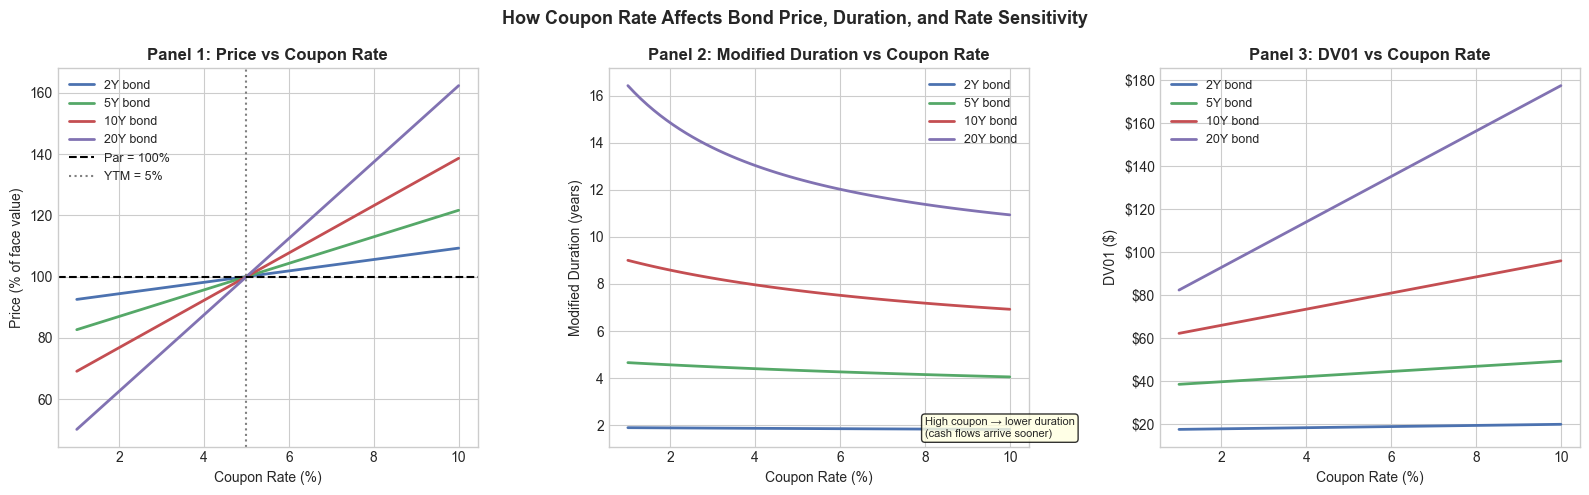

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("How Coupon Rate Affects Bond Price, Duration, and Rate Sensitivity", fontsize=13, fontweight="bold")

coupon_range = np.linspace(0.01, 0.10, 60)
fv_ce = 100_000
ytm_ce = 0.05
maturities_ce = [2, 5, 10, 20]
colors_ce = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Panel 1: Price (% of par) vs coupon rate
ax = axes[0]
for mat_ce, clr_ce in zip(maturities_ce, colors_ce):
    prices_ce = [price_from_ytm(fv_ce, cr_ce, mat_ce, ytm_ce) / fv_ce * 100 for cr_ce in coupon_range]
    ax.plot(coupon_range * 100, prices_ce, color=clr_ce, linewidth=2, label=f"{mat_ce}Y bond")
ax.axhline(100, color="black", linestyle="--", linewidth=1.5, label="Par = 100%")
ax.axvline(ytm_ce * 100, color="grey", linestyle=":", linewidth=1.5, label=f"YTM = {ytm_ce*100:.0f}%")
ax.set_title("Panel 1: Price vs Coupon Rate", fontweight="bold")
ax.set_xlabel("Coupon Rate (%)")
ax.set_ylabel("Price (% of face value)")
ax.legend(fontsize=9)

# Panel 2: Modified duration vs coupon rate
ax = axes[1]
for mat_ce, clr_ce in zip(maturities_ce, colors_ce):
    durs_ce = [modified_duration(fv_ce, cr_ce, mat_ce, ytm_ce) for cr_ce in coupon_range]
    ax.plot(coupon_range * 100, durs_ce, color=clr_ce, linewidth=2, label=f"{mat_ce}Y bond")
ax.set_title("Panel 2: Modified Duration vs Coupon Rate", fontweight="bold")
ax.set_xlabel("Coupon Rate (%)")
ax.set_ylabel("Modified Duration (years)")
ax.legend(fontsize=9)
ax.annotate("High coupon → lower duration\n(cash flows arrive sooner)", xy=(8, 1.5),
            fontsize=8, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Panel 3: DV01 vs coupon rate
ax = axes[2]
for mat_ce, clr_ce in zip(maturities_ce, colors_ce):
    dv01s_ce = [dv01(fv_ce, cr_ce, mat_ce, ytm_ce) for cr_ce in coupon_range]
    ax.plot(coupon_range * 100, dv01s_ce, color=clr_ce, linewidth=2, label=f"{mat_ce}Y bond")
ax.set_title("Panel 3: DV01 vs Coupon Rate", fontweight="bold")
ax.set_xlabel("Coupon Rate (%)")
ax.set_ylabel("DV01 ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### How to read this chart

**Panel 1 — Price vs coupon rate:**
All four lines slope upward: higher coupon → higher price. They all cross at 100% exactly at coupon rate = 5% (the YTM, dotted vertical line). To the left of that line, all bonds are at a discount; to the right, all are at a premium. Longer bonds (purple, 20Y) have a steeper slope — their prices are more sensitive to coupon differences because the higher coupon compounds over more years.

**Panel 2 — Modified duration vs coupon rate:**
All lines slope *downward*. Higher coupon → lower duration. Why? Higher-coupon bonds concentrate more value in early coupon payments (which have low PV weights on the duration timeline). That shifts the "center of gravity" of cash flows closer to today, reducing duration. Longer bonds (20Y) have much higher duration throughout — there is more time for distant cash flows to dominate.

**Panel 3 — DV01 vs coupon rate:**
DV01 rises with coupon rate because a higher-coupon bond has a higher price, and a higher price means more dollars at risk per basis point. The 20Y bond (purple) has the highest DV01 throughout — long maturity combined with high price = maximum sensitivity. Use this chart to understand why a hedge desk must account for both maturity and coupon rate when sizing positions.

## 3. Reading the Bond Portfolio Table

The table above shows one row per bond. Here is a plain-language guide to each column and what to look for.

### Column guide

| Column | What it means | What to look for |
|---|---|---|
| `bond` | Bond label | Name only |
| `face_value` | Principal repaid at maturity | Varies by bond; larger = bigger absolute price and DV01 |
| `coupon_rate` | Annual interest rate in the contract | Compare to market yield to predict premium/discount |
| `coupon_payment` | Cash paid each year = face × coupon rate | The fixed income stream you receive |
| `maturity_years` | Years until bond matures | Longer = higher duration and sensitivity |
| `market_yield` | The rate at which the market discounts this bond | Driven by risk-free rate + credit spread |
| `price` | Present value of all future cash flows | What you pay today |
| `price_pct_of_par` | Price ÷ face value | Above 1.0 → premium; below 1.0 → discount |
| `current_yield` | Annual coupon ÷ current price | Simple income measure; ignores capital gain/loss |
| `ytm_recovered` | YTM solved from the computed price | Should match `market_yield` — confirms pricing is consistent |
| `macaulay_duration` | Weighted average time to receive cash flows | In years; longer = cash flows arrive later |
| `modified_duration` | % price change per 1% yield change | Multiply by yield change to estimate price impact |
| `dv01` | $ price change per 1 basis point yield move | Scales with face value and maturity |
| `convexity` | Curvature of the price-yield relationship | Higher = bond benefits more from large rate drops |

### Patterns to look for in this portfolio

- **Premium bonds** (`price_pct_of_par > 1.0`): coupon rate exceeds market yield. Investors pay above par for the above-market cash flow.
- **Discount bonds** (`price_pct_of_par < 1.0`): coupon rate is below market yield. Price is depressed to compensate.
- **Duration rises with maturity**: longer bonds have more distant cash flows, which are more sensitive to discounting.
- **DV01 rises with face value and maturity**: a large long-dated bond loses the most money per basis point move.
- **`ytm_recovered` ≈ `market_yield`**: this is the round-trip check — price from YTM, then YTM from price, must give back the original number.

### Portfolio summary metrics explained

After the bond table, the notebook computes:
- **Total market value**: sum of all bond prices — what the whole portfolio is worth
- **Weighted modified duration**: the portfolio's blended rate sensitivity — a 1% rate move changes portfolio value by approximately this many percent
- **Portfolio DV01**: sum of all DV01s — the approximate dollar loss for a 1 bp rise in all yields simultaneously
- **Weighted convexity**: the portfolio's overall curvature — helps estimate accuracy beyond the linear duration approximation

In [4]:
portfolio_market_value = portfolio_df["price"].sum()
portfolio_duration = np.average(portfolio_df["modified_duration"], weights=portfolio_df["price"])
portfolio_convexity = np.average(portfolio_df["convexity"], weights=portfolio_df["price"])
portfolio_dv01 = portfolio_df["dv01"].sum()

summary_df = pd.DataFrame(
    {
        "metric": [
            "Total market value",
            "Weighted modified duration",
            "Weighted convexity",
            "Portfolio DV01",
            "Average current yield",
        ],
        "value": [
            portfolio_market_value,
            portfolio_duration,
            portfolio_convexity,
            portfolio_dv01,
            np.average(portfolio_df["current_yield"], weights=portfolio_df["price"]),
        ],
    }
)
summary_df

shock_grid = np.array([-0.02, -0.01, -0.005, 0.0, 0.005, 0.01, 0.02])
scenario_rows = []
for shock in shock_grid:
    shocked_prices = []
    approx_prices = []
    for bond in portfolio:
        row = portfolio_df.loc[portfolio_df["bond"] == bond.name].iloc[0]
        exact_price = price_from_ytm(bond.face_value, bond.coupon_rate, bond.maturity_years, bond.market_yield + shock)
        approx_price = row["price"] + approximate_price_change(row["price"], row["modified_duration"], row["convexity"], shock)
        shocked_prices.append(exact_price)
        approx_prices.append(approx_price)
    scenario_rows.append(
        {
            "yield_shock": shock,
            "portfolio_value_exact": np.sum(shocked_prices),
            "portfolio_value_duration_convexity": np.sum(approx_prices),
        }
    )

scenario_df = pd.DataFrame(scenario_rows)
scenario_df

,yield_shock,portfolio_value_exact,portfolio_value_duration_convexity
0,-0.0200,"12,002,138.8595","11,957,026.3338"
1,-0.0100,"10,862,962.6457","10,857,696.9150"
2,-0.0050,"10,360,994.5540","10,360,357.6653"
3,0.0000,"9,897,902.0554","9,897,902.0554"
4,0.0050,"9,469,732.3344","9,470,330.0854"
5,0.0100,"9,073,003.6002","9,077,641.7552"
6,0.0200,"8,361,933.1637","8,396,916.0142"


## 4. How to Read the Portfolio Charts

The 4-panel chart below visualises four different aspects of the portfolio.

### Panel 1 — Simulated Yield Curve

- **x-axis**: maturity in years (2Y through 30Y)
- **y-axis**: market yield for each bond in %
- The upward slope reflects a normal yield curve — longer bonds pay more to compensate for locking up capital longer
- The slight randomness comes from simulated spreads above the base curve

### Panel 2 — Price as % of Par vs Maturity

- Each bubble is one bond
- **Above 100%** = premium bond (coupon rate > yield): investors overpay for above-market income
- **Below 100%** = discount bond (coupon rate < yield): bond is cheap to compensate for below-market coupon
- **Bubble colour** = coupon rate (dark green = high coupon)
- **Bubble size** = face value (bigger bubble = larger notional)

Look for the pattern: bonds with darker colour (higher coupon) tend to sit higher (above par).

### Panel 3 — Modified Duration by Bond

- **Taller bar = more rate sensitive**
- Duration grows with maturity because distant cash flows are more sensitive to discounting
- A 20Y bond might have duration ≈ 12 years, meaning it loses ≈12% for a 1% rise in yield
- Note that duration is always shorter than maturity because coupons are received before maturity, pulling the weighted average earlier

### Panel 4 — Portfolio Value Under Parallel Yield Shocks

- **x-axis**: yield shock in basis points (negative = rates fell, positive = rates rose)
- **y-axis**: portfolio value in millions
- **Solid line**: exact repricing — recomputes every bond price under the shocked yield
- **Dashed line**: duration + convexity approximation — uses the sensitivity formulas

The two lines should be close for small shocks (−50 bp to +50 bp). They diverge slightly for large shocks, showing where the linear approximation breaks down. Convexity (the curved term) makes the approximation better than duration alone.

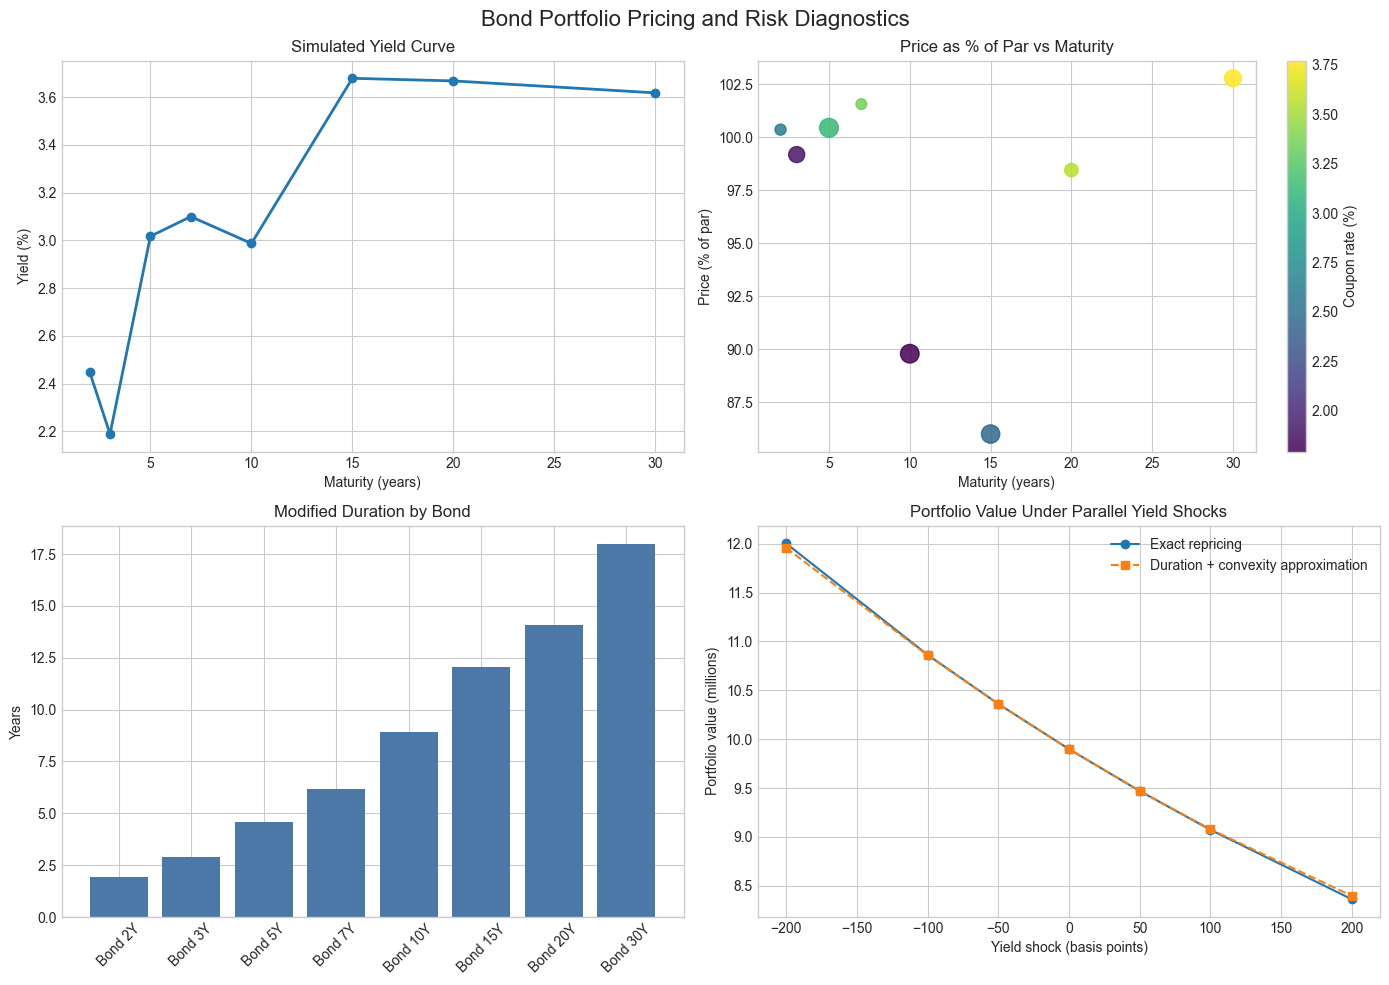

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(portfolio_df["maturity_years"], 100 * portfolio_df["market_yield"], marker="o", linewidth=2)
axes[0, 0].set_title("Simulated Yield Curve")
axes[0, 0].set_xlabel("Maturity (years)")
axes[0, 0].set_ylabel("Yield (%)")

scatter = axes[0, 1].scatter(
    portfolio_df["maturity_years"],
    portfolio_df["price_pct_of_par"] * 100,
    s=portfolio_df["face_value"] / 10_000,
    c=portfolio_df["coupon_rate"] * 100,
    cmap="viridis",
    alpha=0.85,
)
axes[0, 1].set_title("Price as % of Par vs Maturity")
axes[0, 1].set_xlabel("Maturity (years)")
axes[0, 1].set_ylabel("Price (% of par)")
colorbar = fig.colorbar(scatter, ax=axes[0, 1])
colorbar.set_label("Coupon rate (%)")

axes[1, 0].bar(portfolio_df["bond"], portfolio_df["modified_duration"], color="#4C78A8")
axes[1, 0].set_title("Modified Duration by Bond")
axes[1, 0].set_ylabel("Years")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].plot(10_000 * scenario_df["yield_shock"], scenario_df["portfolio_value_exact"] / 1e6, marker="o", label="Exact repricing")
axes[1, 1].plot(
    10_000 * scenario_df["yield_shock"],
    scenario_df["portfolio_value_duration_convexity"] / 1e6,
    marker="s",
    linestyle="--",
    label="Duration + convexity approximation",
)
axes[1, 1].set_title("Portfolio Value Under Parallel Yield Shocks")
axes[1, 1].set_xlabel("Yield shock (basis points)")
axes[1, 1].set_ylabel("Portfolio value (millions)")
axes[1, 1].legend()

fig.suptitle("Bond Portfolio Pricing and Risk Diagnostics", fontsize=16)
fig.tight_layout()
plt.show()

### How to read the portfolio charts

**Panel 1 — Yield curve:** The simulated yield curve plots each bond's market yield against its maturity. The generally upward slope is a normal yield curve — investors require higher returns for longer commitments. Each dot is one bond; note slight randomness representing individual bond spreads.

**Panel 2 — Price as % of par:** Bubbles above 100% are premium bonds (coupon > yield), below 100% are discount bonds (coupon < yield). Darker colour = higher coupon rate. Larger bubble = larger face value. The overall shape shows how the price discount deepens as maturity increases (longer bonds are further from par when yields are relatively high).

**Panel 3 — Modified duration by bond:** Duration grows with maturity. The tallest bars belong to the longest-dated bonds. This is the rate-sensitivity rank: if yields rise 1%, bonds with taller bars lose more % of their value. A 20Y bond with duration ≈ 12 loses roughly 12% per 1% yield rise.

**Panel 4 — Portfolio value under yield shocks:** The solid curve (exact repricing) and dashed curve (duration + convexity approximation) show how the full portfolio responds to parallel yield moves. The gap between them — visible at extreme shocks — is where the linear approximation breaks down. Both curves bow upward: convexity means gains from falling rates exceed losses from rising rates by the same amount.

## 5. On-the-Run vs Off-the-Run Bonds

### 5.1 What are OTR and XTR bonds?

When a government (e.g., the US Treasury) issues new bonds, the most recently issued bond for a given maturity is called **On-the-Run (OTR)**. All older bonds of the same maturity are called **Off-the-Run (XTR)**.

For example, the US Treasury might issue a new 10-year bond in March. That becomes the OTR 10-year. The bond issued in December is now off-the-run — it matures in about 9.5 years now, and it trades less frequently.

### 5.2 Why do they trade at different yields?

Both bonds repay the same government, so there is essentially **no credit difference**. Yet OTR bonds typically trade at **lower yields (higher prices)** than XTR bonds.

The reason is **liquidity premium**:
- OTR bonds are the most recently issued and are actively traded in large volume
- They are cheaper to buy and sell (narrow bid-ask spreads)
- Investors pay a premium for this ease of trading — just like you might pay slightly more for a house in a busy, well-connected neighbourhood
- XTR bonds are less liquid — they trade less, are harder to sell quickly, and carry a slightly higher yield to compensate

**Liquidity premium** = the extra yield (extra return) demanded by investors to hold a less liquid bond.

### 5.3 The OTR/XTR relative value trade

Traders exploit the yield difference between OTR and XTR bonds:

1. **Identify** that OTR yield = 3.40%, XTR yield = 3.62% → spread = 22 bp
2. **View**: OTR is "expensive" (rich), XTR is "cheap". The spread might compress if the OTR bond becomes off-the-run next quarter.
3. **Trade**: Buy XTR (expect price to rise as spread compresses), short OTR (expect price to fall relative to XTR)
4. **Hedge**: Size the hedge ratio so that the two legs have equal DV01 — so a parallel move in all rates does not generate profit or loss. You only profit from the **spread change**.

### 5.4 The DV01 hedge ratio

If the two bonds have different DV01s, you need to adjust the number of bonds in each leg:

$$\text{Hedge ratio} = \frac{\text{DV01 of XTR}}{\text{DV01 of OTR}}$$

This tells you: for every 1 unit of XTR you buy, short this many units of OTR to neutralise parallel rate sensitivity.

### 5.5 What the charts show

The charts below display:
1. **OTR and XTR price-yield curves** — both curves together, showing that XTR always trades at a higher yield (lower price) than OTR at each point
2. **Yield spread across the compression grid** — shows how the spread between OTR and XTR changes from +30 bp to −10 bp, and the resulting P&L for the trade
3. **Unhedged vs hedged P&L** — the hedged book isolates the spread move; the unhedged book is also exposed to parallel rate moves
4. **DV01 breakdown** — OTR vs XTR DV01 and the resulting hedge ratio

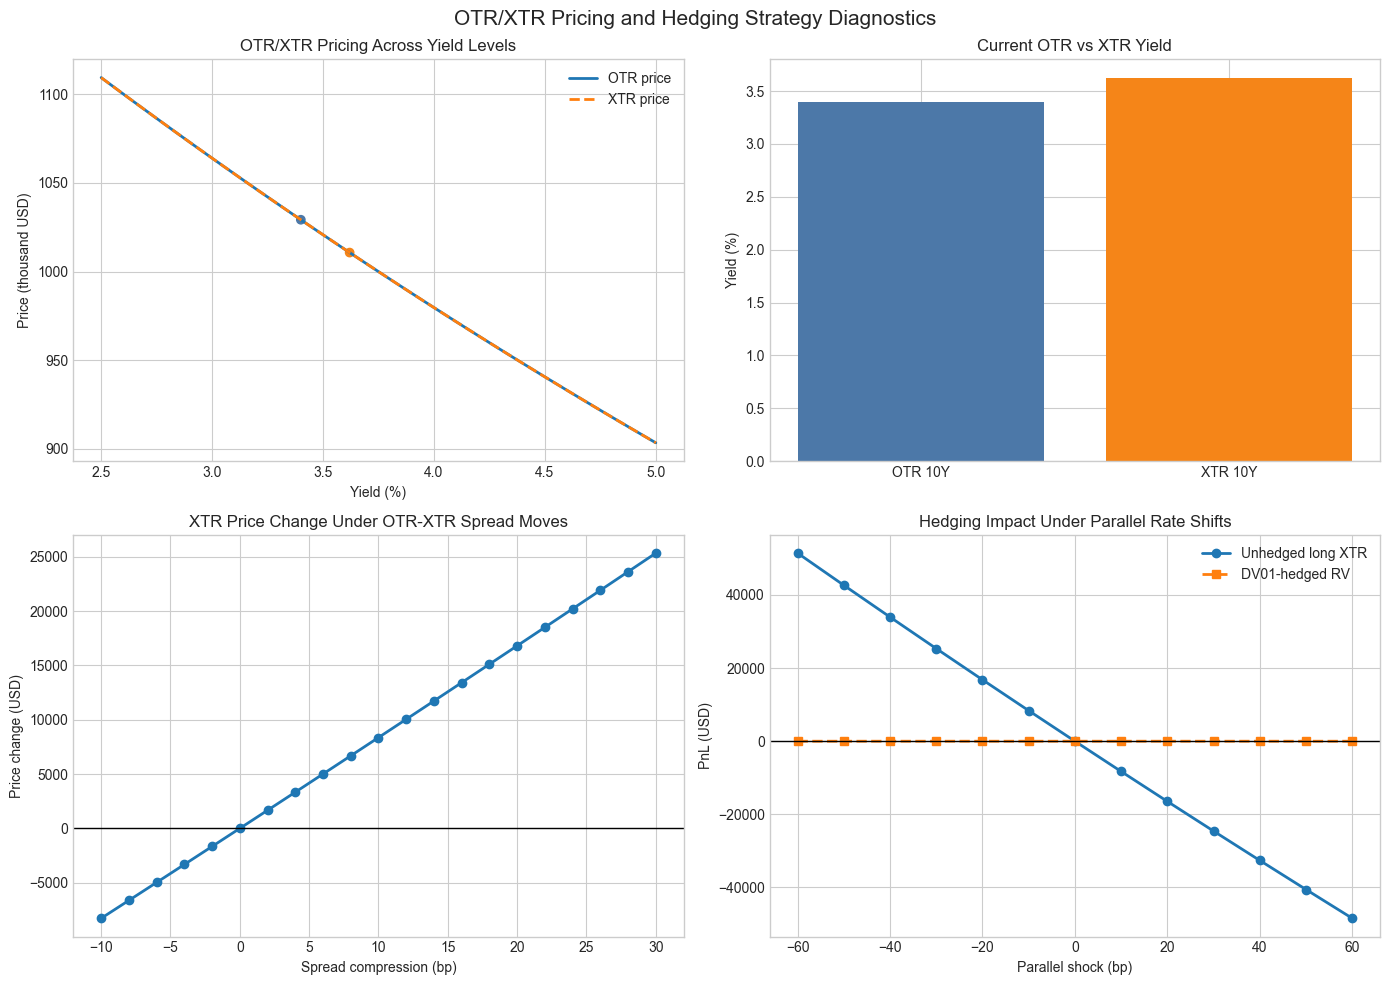

In [4]:
otr_xtr_face = 1_000_000
otr_coupon = 0.0375
xtr_coupon = 0.0375
otr_maturity = 10
xtr_maturity = 10

# Assume OTR trades richer (lower yield) because of benchmark liquidity.
otr_yield = 0.0340
xtr_yield = 0.0362

otr_price = price_from_ytm(otr_xtr_face, otr_coupon, otr_maturity, otr_yield)
xtr_price = price_from_ytm(otr_xtr_face, xtr_coupon, xtr_maturity, xtr_yield)

# Practical yield-calculation use case: infer XTR yield from an observed market price.
xtr_ytm_from_price = ytm_from_price(otr_xtr_face, xtr_coupon, xtr_maturity, xtr_price)

otr_dv01 = dv01(otr_xtr_face, otr_coupon, otr_maturity, otr_yield)
xtr_dv01 = dv01(otr_xtr_face, xtr_coupon, xtr_maturity, xtr_yield)
dv01_hedge_ratio = xtr_dv01 / otr_dv01

otr_xtr_df = pd.DataFrame(
    [
        {
            "bond_type": "OTR 10Y",
            "coupon_rate": otr_coupon,
            "yield": otr_yield,
            "price": otr_price,
            "price_pct_par": 100 * otr_price / otr_xtr_face,
            "dv01": otr_dv01,
        },
        {
            "bond_type": "XTR 10Y",
            "coupon_rate": xtr_coupon,
            "yield": xtr_yield,
            "price": xtr_price,
            "price_pct_par": 100 * xtr_price / otr_xtr_face,
            "dv01": xtr_dv01,
        },
    ]
)

otr_xtr_spread_bp = 10_000 * (xtr_yield - otr_yield)

use_case_df = pd.DataFrame(
    {
        "use_case": [
            "Observed OTR-XTR spread (bp)",
            "XTR yield recovered from observed price (%)",
            "OTR price premium vs XTR (USD)",
            "DV01 hedge ratio (short OTR per 1 long XTR)",
        ],
        "value": [
            otr_xtr_spread_bp,
            100 * xtr_ytm_from_price,
            otr_price - xtr_price,
            dv01_hedge_ratio,
        ],
    }
)

otr_xtr_df, use_case_df

# Pricing curves across yields to visualize relative richness.
yield_grid = np.linspace(0.025, 0.05, 120)
otr_curve_price = np.array([price_from_ytm(otr_xtr_face, otr_coupon, otr_maturity, y) for y in yield_grid])
xtr_curve_price = np.array([price_from_ytm(otr_xtr_face, xtr_coupon, xtr_maturity, y) for y in yield_grid])

# Spread-compression RV example: keep OTR fixed and move XTR spread.
compression_grid_bp = np.arange(-10, 31, 2)
rv_rows = []
for compression in compression_grid_bp:
    new_xtr_yield = xtr_yield - compression / 10_000
    new_xtr_price = price_from_ytm(otr_xtr_face, xtr_coupon, xtr_maturity, new_xtr_yield)
    pnl = new_xtr_price - xtr_price
    rv_rows.append({"spread_compression_bp": compression, "xtr_price_change_usd": pnl})

rv_df = pd.DataFrame(rv_rows)

# Hedging strategy example: long XTR and short DV01-matched OTR under parallel shifts.
parallel_shock_bp = np.arange(-60, 65, 10)
hedge_rows = []
for shock in parallel_shock_bp:
    shocked_otr_price = price_from_ytm(otr_xtr_face, otr_coupon, otr_maturity, otr_yield + shock / 10_000)
    shocked_xtr_price = price_from_ytm(otr_xtr_face, xtr_coupon, xtr_maturity, xtr_yield + shock / 10_000)

    unhedged_pnl = shocked_xtr_price - xtr_price
    hedge_leg_pnl = -dv01_hedge_ratio * (shocked_otr_price - otr_price)
    hedged_pnl = unhedged_pnl + hedge_leg_pnl

    hedge_rows.append(
        {
            "parallel_shock_bp": shock,
            "unhedged_xtr_pnl_usd": unhedged_pnl,
            "dv01_hedged_pnl_usd": hedged_pnl,
        }
    )

hedge_df = pd.DataFrame(hedge_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(100 * yield_grid, otr_curve_price / 1_000, linewidth=2, label="OTR price")
axes[0, 0].plot(100 * yield_grid, xtr_curve_price / 1_000, linewidth=2, linestyle="--", label="XTR price")
axes[0, 0].scatter([100 * otr_yield, 100 * xtr_yield], [otr_price / 1_000, xtr_price / 1_000], color=["#4C78A8", "#F58518"])
axes[0, 0].set_title("OTR/XTR Pricing Across Yield Levels")
axes[0, 0].set_xlabel("Yield (%)")
axes[0, 0].set_ylabel("Price (thousand USD)")
axes[0, 0].legend()

axes[0, 1].bar(otr_xtr_df["bond_type"], otr_xtr_df["yield"] * 100, color=["#4C78A8", "#F58518"])
axes[0, 1].set_title("Current OTR vs XTR Yield")
axes[0, 1].set_ylabel("Yield (%)")

axes[1, 0].plot(rv_df["spread_compression_bp"], rv_df["xtr_price_change_usd"], marker="o", linewidth=2)
axes[1, 0].axhline(0.0, color="black", linewidth=1)
axes[1, 0].set_title("XTR Price Change Under OTR-XTR Spread Moves")
axes[1, 0].set_xlabel("Spread compression (bp)")
axes[1, 0].set_ylabel("Price change (USD)")

axes[1, 1].plot(hedge_df["parallel_shock_bp"], hedge_df["unhedged_xtr_pnl_usd"], marker="o", linewidth=2, label="Unhedged long XTR")
axes[1, 1].plot(hedge_df["parallel_shock_bp"], hedge_df["dv01_hedged_pnl_usd"], marker="s", linewidth=2, linestyle="--", label="DV01-hedged RV")
axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].set_title("Hedging Impact Under Parallel Rate Shifts")
axes[1, 1].set_xlabel("Parallel shock (bp)")
axes[1, 1].set_ylabel("PnL (USD)")
axes[1, 1].legend()

fig.suptitle("OTR/XTR Pricing and Hedging Strategy Diagnostics", fontsize=15)
fig.tight_layout()
plt.show()

### How to read the OTR/XTR charts

**Panel 1 — OTR and XTR price-yield curves:**
Both curves show how each bond's price changes with yield. Notice the XTR curve sits to the right of the OTR curve at each price level — meaning the XTR always offers a higher yield for the same price. The gap between the two curves at any price level represents the liquidity premium.

**Panel 2 — Spread compression and P&L:**
The x-axis shows different scenarios for the OTR/XTR yield spread (from +30 bp, where XTR is very cheap, to −10 bp, where OTR has become cheaper). The y-axis shows the P&L from the relative value trade. When the spread compresses (moves left on the x-axis), the trade profits. The trade is set up to profit from this convergence.

**Panel 3 — Hedged vs unhedged P&L:**
The solid line (unhedged) fluctuates with the overall rate level — parallel shifts in rates generate profit or loss even if the spread stays constant. The dashed line (hedged) is much flatter for parallel moves, isolating only the spread change as the profit source. A good hedge flattens the P&L to parallel rate moves while retaining sensitivity to spread moves.

**Panel 4 — DV01 comparison and hedge ratio:**
The bar chart shows the DV01 of the OTR and XTR legs. The hedge ratio = XTR DV01 ÷ OTR DV01. If both bonds have similar DV01, the ratio is near 1:1. If the XTR has a higher DV01 (perhaps because its duration is slightly longer), you need fewer XTR units per OTR unit to equalise rate sensitivity.

## Main Takeaways

### Core rules to remember

1. **A bond is a loan with fixed cash flows.** You receive regular coupons plus face value at maturity. Nothing changes regardless of market conditions.

2. **Price and yield move in opposite directions.** Always. If yields rise, prices fall. If yields fall, prices rise. This is the single most important rule in bond markets.

3. **YTM is the return you earn from today's price.** It is the discount rate that makes the present value of all future cash flows exactly equal to the market price. It is solved numerically.

4. **Coupon vs yield determines premium or discount.** Coupon > yield → premium (above par). Coupon < yield → discount (below par). Coupon ≈ yield → par.

5. **Duration measures rate sensitivity.** Modified duration tells you the approximate % price change per 1% yield move. A 10-year modified duration means ~10% loss for a 1% rate rise.

6. **Longer bonds are more sensitive.** A 30Y bond reacts far more to rate moves than a 2Y bond because most of its value sits in distant, heavily-discounted cash flows.

7. **Convexity is your friend as a bond buyer.** Due to convexity, bond prices rise more when yields fall than they fall when yields rise by the same amount. Higher convexity = more of this beneficial asymmetry.

8. **DV01 = dollar risk per basis point.** Use it to size hedges. To neutralise DV01 risk, short a hedge instrument with equal DV01.

---

### Beginner checklist — can you answer these?

- [ ] A bond has face value $100,000, 4% coupon, and 5-year maturity. Market yield is 3%. Is it a premium or discount bond? Why?
- [ ] Yields rise by 50 bp. A bond has modified duration of 8. Roughly how much does the price change in %?
- [ ] What is YTM and how does it differ from the coupon rate?
- [ ] Why does a 30Y bond lose more value than a 2Y bond for the same 100 bp yield rise?
- [ ] What does a DV01 of $850 tell you about hedging?
- [ ] If OTR and XTR bonds have the same maturity, why do they trade at different yields?
- [ ] What does it mean to be "DV01-hedged" in an OTR/XTR relative value trade?

---

### Topics to explore next

- **Semi-annual coupons**: most government bonds pay every 6 months — requires adjusted discounting
- **Accrued interest and clean/dirty price**: the price quoted vs the price actually paid
- **Credit spreads**: corporate bonds trade above the risk-free rate; the extra spread reflects default risk
- **Callable bonds**: some bonds can be repaid early — changes the duration and pricing
- **Full term-structure discounting**: instead of a single YTM, use different discount rates for each cash flow date
- **Key rate durations (KRD)**: how sensitive a bond is to specific points on the yield curve, not just parallel shifts